# CSI Data Pipeline v0: Parsing, Features, and Metrics

This notebook implements Data Pipeline v0 for device-free Wi-Fi presence sensing with ESP32-S3 CSI captures in HT40 mode.

The pipeline converts raw CSV files plus companion metadata JSON files into a reproducible tabular feature dataset for binary presence detection. It performs parsing, validation, cleaning, I/Q to complex CSI conversion, amplitude extraction, shared HT40 valid-subcarrier masking, optional filtering, active-interval selection, non-overlapping 2-second windowing, official v0 feature extraction, dataset assembly, EDA, and pipeline metrics.

The official v0 feature set contains exactly four natural-scale amplitude features per retained HT40 subcarrier: variance, median absolute deviation, range, and interquartile range. RSSI statistics, PCA, correlation plots, and related diagnostics in this notebook are EDA only and are not saved as official model features.


## 1. Imports and Configuration

Important paths and all processing parameters are configurable in this cell. The default data directory points to the current HT40 pilot dataset, but `MANUAL_CSV_PATHS` can be used to process an explicit list of files.


In [1]:
from __future__ import annotations

import ast
import json
import math
import warnings
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import signal

try:
    import pywt

    PYWT_AVAILABLE = True
except ImportError:
    pywt = None
    PYWT_AVAILABLE = False

NOTEBOOK_VERSION = "v0.1.0"

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "pilot" / "data"
OUTPUT_DIR = PROJECT_ROOT / "pilot" / "outputs" / "pipeline_v0"
FIGURES_DIR = OUTPUT_DIR / "figures"
FEATURE_OUTPUT_CSV = OUTPUT_DIR / "features_v0_ht40.csv"
FEATURE_OUTPUT_PARQUET = OUTPUT_DIR / "features_v0_ht40.parquet"
VALID_SUBCARRIER_MAPPING_CSV = OUTPUT_DIR / "valid_subcarrier_mapping_v0.csv"
PIPELINE_REPORT_JSON = OUTPUT_DIR / "pipeline_report_v0.json"

# Leave this list empty to discover all CSV files in DATA_DIR.
MANUAL_CSV_PATHS: list[Path] = []
REQUIRED_METADATA_STATUS = "VALID"

WINDOW_SECONDS = 2.0
VALID_SUBCARRIER_MEAN_AMP_THRESHOLD = 0.5
MIN_SHARED_VALID_SUBCARRIERS = 40
MIN_ABSOLUTE_SAMPLES_PER_WINDOW = 5
MIN_WINDOW_SAMPLE_RATE_FRACTION = 0.5

FILTER_TYPE = "none"  # Options: "none", "butterworth", "wavelet".
BUTTERWORTH_ORDER = 3
BUTTERWORTH_CUTOFF_HZ = 3.0
WAVELET_NAME = "db4"
WAVELET_LEVEL: int | None = None

ACTIVE_INTERVAL_FALLBACK = "full"  # Options: "full", "trim".
FALLBACK_TRIM_SECONDS = 0.0

LABEL_MAP = {
    "empty": 0,
    "occupied_still": 1,
    "occupied_moving": 1,
}

RANDOM_SEED = 42
MAX_CORRELATION_FEATURES = 48
MAX_PCA_ROWS = 5000
SELECTED_VALID_SUBCARRIERS_FOR_EDA = [0, 1, 2, 10, 25, 50, 100, 150]

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(RANDOM_SEED)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"PyWavelets available: {PYWT_AVAILABLE}")


Project root: /home/xavier/code/wifi-csi-presence-detection
Data directory: /home/xavier/code/wifi-csi-presence-detection/pilot/data
Output directory: /home/xavier/code/wifi-csi-presence-detection/pilot/outputs/pipeline_v0
PyWavelets available: True


## 2. Session Discovery

This section discovers CSI CSV files and their companion metadata JSON files. The expected metadata filename is the CSV stem followed by `_meta.json`.

Only sessions whose metadata contains `timing.status = "VALID"` are eligible for processing. Invalid sessions are shown in the discovery table and excluded from every downstream pipeline step.


In [2]:
def load_metadata(meta_path: Path | None) -> dict[str, Any]:
    """Load a metadata JSON file, returning an empty dictionary when unavailable."""
    if meta_path is None:
        return {}
    meta_path = Path(meta_path)
    if not meta_path.exists():
        warnings.warn(f"Metadata file not found: {meta_path}")
        return {}
    with meta_path.open("r", encoding="utf-8") as fp:
        return json.load(fp)


def infer_label_from_filename(csv_path: Path) -> str | None:
    """Infer the session label from a CSV filename when metadata does not provide it."""
    name = csv_path.stem.lower()
    for label_name in sorted(LABEL_MAP, key=len, reverse=True):
        if label_name in name:
            return label_name
    return None


def infer_label_from_metadata_or_filename(meta: dict[str, Any], csv_path: Path) -> str | None:
    """Infer the label from metadata first and then from the filename."""
    label_name = meta.get("session", {}).get("label")
    if isinstance(label_name, str) and label_name.strip():
        return label_name.strip()
    return infer_label_from_filename(csv_path)


def metadata_validation_details(meta: dict[str, Any]) -> tuple[str | None, str | None, bool]:
    """Return metadata validity status, invalidation reason, and validity flag."""
    timing = meta.get("timing", {}) if isinstance(meta, dict) else {}
    status_raw = timing.get("status")
    status = str(status_raw).strip().upper() if status_raw is not None else None
    invalidation_reason = timing.get("invalidation_reason")
    is_valid = status == REQUIRED_METADATA_STATUS
    return status, invalidation_reason, is_valid


def discover_sessions(data_dir: Path, manual_csv_paths: list[Path] | None = None) -> pd.DataFrame:
    """Discover CSV sessions and companion metadata files."""
    if manual_csv_paths:
        csv_paths = [Path(path).expanduser().resolve() for path in manual_csv_paths]
    else:
        csv_paths = sorted(Path(data_dir).glob("*.csv"))

    records: list[dict[str, Any]] = []
    for csv_path in csv_paths:
        meta_path = csv_path.with_name(f"{csv_path.stem}_meta.json")
        meta_exists = meta_path.exists()
        meta = load_metadata(meta_path if meta_exists else None)
        label_name = infer_label_from_metadata_or_filename(meta, csv_path)
        metadata_status, invalidation_reason, is_metadata_valid = metadata_validation_details(meta)
        session_id = meta.get("session", {}).get("id") if isinstance(meta, dict) else None
        records.append(
            {
                "csv_path": csv_path,
                "csv_filename": csv_path.name,
                "metadata_path": meta_path if meta_exists else None,
                "metadata_filename": meta_path.name if meta_exists else None,
                "session_id": session_id or csv_path.stem,
                "label_name": label_name,
                "metadata_status": metadata_status,
                "is_metadata_valid": is_metadata_valid,
                "invalidation_reason": invalidation_reason,
                "file_size_mb": csv_path.stat().st_size / (1024 * 1024),
            }
        )

    return pd.DataFrame.from_records(records)


sessions_table = discover_sessions(DATA_DIR, MANUAL_CSV_PATHS)
if sessions_table.empty:
    raise FileNotFoundError(
        f"No CSV files were found in {DATA_DIR}. Update DATA_DIR or MANUAL_CSV_PATHS."
    )

sessions_to_process_table = sessions_table.loc[sessions_table["is_metadata_valid"]].copy()
excluded_sessions_table = sessions_table.loc[~sessions_table["is_metadata_valid"]].copy()

if not excluded_sessions_table.empty:
    warnings.warn(
        "Excluding sessions whose metadata timing.status is not "
        f"{REQUIRED_METADATA_STATUS!r}: "
        f"{excluded_sessions_table['csv_filename'].tolist()}"
    )

if sessions_to_process_table.empty:
    raise ValueError(
        "No sessions with valid metadata status were found. "
        f"Expected timing.status == {REQUIRED_METADATA_STATUS!r}."
    )

display(
    sessions_table[
        [
            "csv_filename",
            "metadata_filename",
            "session_id",
            "label_name",
            "metadata_status",
            "is_metadata_valid",
            "invalidation_reason",
            "file_size_mb",
        ]
    ].assign(file_size_mb=lambda df: df["file_size_mb"].round(2))
)

print("Sessions selected for processing:")
display(
    sessions_to_process_table[
        ["csv_filename", "metadata_filename", "session_id", "label_name", "metadata_status"]
    ]
)


/tmp/ipykernel_88020/3923529737.py:83: UserWarning: Excluding sessions whose metadata timing.status is not 'VALID': ['session_A_empty_20260502_1200.csv', 'session_B_empty_20260502_1223.csv']
  warnings.warn(


,csv_filename,metadata_filename,session_id,label_name,metadata_status,is_metadata_valid,invalidation_reason,file_size_mb
0,session_A_empty_20260502_1200.csv,session_A_empty_20260502_1200_meta.json,A,empty,INVALID,False,t1 and t2 timestamps do not match expected tim...,23.82
1,session_B_empty_20260502_1223.csv,session_B_empty_20260502_1223_meta.json,B,empty,INVALID,False,t1 timestamp do not match expected times based...,23.37
2,session_C_empty_20260502_1240.csv,session_C_empty_20260502_1240_meta.json,C,empty,VALID,True,,23.24
3,session_D_occupied_still_20260502_1317.csv,session_D_occupied_still_20260502_1317_meta.json,D,occupied_still,VALID,True,,19.52
4,session_E_occupied_moving_20260502_1404.csv,session_E_occupied_moving_20260502_1404_meta.json,E,occupied_moving,VALID,True,,20.36


Sessions selected for processing:


,csv_filename,metadata_filename,session_id,label_name,metadata_status
2,session_C_empty_20260502_1240.csv,session_C_empty_20260502_1240_meta.json,C,empty,VALID
3,session_D_occupied_still_20260502_1317.csv,session_D_occupied_still_20260502_1317_meta.json,D,occupied_still,VALID
4,session_E_occupied_moving_20260502_1404.csv,session_E_occupied_moving_20260502_1404_meta.json,E,occupied_moving,VALID


## 3. Parsing Utilities

ESP32 CSI payloads are represented as interleaved I/Q values. For this dataset, each row with `len = 384` contains 192 raw complex subcarriers. The parser computes these dimensions from the data instead of assuming a fixed HT20 shape.


In [3]:
def parse_host_timestamp(value: Any) -> pd.Timestamp:
    """Parse a host timestamp and return a timezone-naive local pandas Timestamp."""
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return pd.NaT
    try:
        timestamp = pd.to_datetime(value, errors="coerce")
    except Exception:
        return pd.NaT
    if pd.isna(timestamp):
        return pd.NaT
    if getattr(timestamp, "tzinfo", None) is not None:
        timestamp = timestamp.tz_localize(None)
    return pd.Timestamp(timestamp)


def parse_csi_array(data_str: Any) -> np.ndarray | None:
    """Parse a CSI data field into a one-dimensional numeric NumPy array."""
    if isinstance(data_str, np.ndarray):
        raw = data_str
    elif isinstance(data_str, list | tuple):
        raw = np.asarray(data_str)
    elif isinstance(data_str, str):
        text = data_str.strip()
        if not text:
            return None
        try:
            raw = np.asarray(json.loads(text))
        except json.JSONDecodeError:
            try:
                raw = np.asarray(ast.literal_eval(text))
            except (ValueError, SyntaxError):
                return None
    else:
        return None

    if raw.ndim != 1:
        return None
    try:
        raw = raw.astype(np.float64)
    except (TypeError, ValueError):
        return None
    if not np.all(np.isfinite(raw)):
        return None
    return raw


def raw_iq_to_complex(raw: np.ndarray) -> np.ndarray:
    """Convert ESP32 interleaved [imag_0, real_0, ...] CSI into real + 1j * imag."""
    if raw.ndim != 1:
        raise ValueError("Raw CSI vector must be one-dimensional.")
    if len(raw) % 2 != 0:
        raise ValueError(f"Raw CSI vector length must be even, got {len(raw)}.")
    imag = raw[0::2]
    real = raw[1::2]
    return real.astype(np.float64) + 1j * imag.astype(np.float64)


def get_active_interval_from_metadata(
    meta: dict[str, Any],
) -> tuple[pd.Timestamp | None, pd.Timestamp | None, str]:
    """Extract the preferred active condition interval from metadata."""
    timing = meta.get("timing", {}) if isinstance(meta, dict) else {}
    start = parse_host_timestamp(timing.get("t1_condition_start"))
    end = parse_host_timestamp(timing.get("t2_condition_end"))
    if pd.isna(start) or pd.isna(end) or start >= end:
        return None, None, "missing_or_invalid_metadata_interval"
    return start, end, "metadata_t1_t2"


def detect_valid_subcarriers(
    amplitude_matrix: np.ndarray,
    threshold: float = VALID_SUBCARRIER_MEAN_AMP_THRESHOLD,
) -> np.ndarray:
    """Detect valid subcarriers from mean amplitude using a configurable threshold."""
    if amplitude_matrix.ndim != 2:
        raise ValueError("Amplitude matrix must have shape samples by subcarriers.")
    mean_amplitude = np.nanmean(amplitude_matrix, axis=0)
    return np.isfinite(mean_amplitude) & (mean_amplitude > threshold)


def median_absolute_deviation(values: np.ndarray, axis: int = 0) -> np.ndarray:
    """Compute the median absolute deviation around the median."""
    median = np.nanmedian(values, axis=axis, keepdims=True)
    return np.nanmedian(np.abs(values - median), axis=axis)


## 4. Session Loading and Validation

Each session is loaded independently. Rows with malformed CSI payloads, invalid timestamps, inconsistent `len` values, inconsistent raw vector lengths, or non-even CSI vectors are removed with structured counts in the returned metrics.


In [4]:
def _series_or_empty_numeric(df: pd.DataFrame, column: str) -> np.ndarray | None:
    """Return a numeric column as a NumPy array when present."""
    if column not in df.columns:
        return None
    return pd.to_numeric(df[column], errors="coerce").to_numpy(dtype=np.float64)


def _safe_mode_int(values: pd.Series) -> int | None:
    """Return the most common integer value in a series, or None when unavailable."""
    numeric = pd.to_numeric(values, errors="coerce").dropna().astype(int)
    if numeric.empty:
        return None
    return int(numeric.mode().iloc[0])


def _rssi_summary(rssi: np.ndarray | None) -> dict[str, float | None]:
    """Summarize RSSI values when present."""
    if rssi is None or len(rssi) == 0 or np.all(np.isnan(rssi)):
        return {"mean": None, "std": None, "min": None, "max": None}
    return {
        "mean": float(np.nanmean(rssi)),
        "std": float(np.nanstd(rssi)),
        "min": float(np.nanmin(rssi)),
        "max": float(np.nanmax(rssi)),
    }


def load_session(csv_path: Path, meta_path: Path | None = None) -> dict[str, Any]:
    """Load, validate, and convert one CSI CSV session into arrays and metrics."""
    csv_path = Path(csv_path)
    meta = load_metadata(meta_path)
    metadata_status, invalidation_reason, is_metadata_valid = metadata_validation_details(meta)
    if not is_metadata_valid:
        raise ValueError(
            f"{csv_path.name} has metadata timing.status={metadata_status!r}; "
            f"only {REQUIRED_METADATA_STATUS!r} sessions are allowed. "
            f"Invalidation reason: {invalidation_reason or 'not provided'}"
        )

    label_name = infer_label_from_metadata_or_filename(meta, csv_path)
    if label_name not in LABEL_MAP:
        warnings.warn(
            f"Label {label_name!r} for {csv_path.name} is not in LABEL_MAP. "
            "Add an explicit mapping before using this session."
        )
        label_value = None
    else:
        label_value = LABEL_MAP[label_name]

    df_raw = pd.read_csv(csv_path)
    raw_rows = int(len(df_raw))
    df = df_raw.copy()

    if "type" in df.columns:
        df = df.loc[df["type"].astype(str).eq("CSI_DATA")].copy()
    csi_rows = int(len(df))

    if "timestamp_host" not in df.columns:
        raise ValueError(f"{csv_path.name} is missing required column timestamp_host.")
    if "data" not in df.columns:
        raise ValueError(f"{csv_path.name} is missing required column data.")

    df["timestamp_host_parsed"] = df["timestamp_host"].map(parse_host_timestamp)
    invalid_timestamp_mask = df["timestamp_host_parsed"].isna()
    invalid_timestamp_rows = int(invalid_timestamp_mask.sum())
    df = df.loc[~invalid_timestamp_mask].copy()

    parsed_arrays = df["data"].map(parse_csi_array)
    parse_error_mask = parsed_arrays.isna()
    parse_error_rows = int(parse_error_mask.sum())
    df = df.loc[~parse_error_mask].copy()
    parsed_arrays = parsed_arrays.loc[~parse_error_mask]
    df["parsed_csi"] = parsed_arrays

    if df.empty:
        raise ValueError(f"{csv_path.name} has no valid CSI rows after timestamp and data parsing.")

    raw_lengths = df["parsed_csi"].map(len)
    expected_len_from_column = _safe_mode_int(df["len"]) if "len" in df.columns else None
    expected_raw_length = expected_len_from_column or int(raw_lengths.mode().iloc[0])
    if expected_raw_length % 2 != 0:
        raise ValueError(
            f"{csv_path.name} has odd expected raw CSI vector length {expected_raw_length}."
        )

    length_mismatch_mask = raw_lengths.ne(expected_raw_length)
    if "len" in df.columns:
        len_column = pd.to_numeric(df["len"], errors="coerce")
        length_mismatch_mask = length_mismatch_mask | len_column.ne(expected_raw_length)
    length_mismatch_rows = int(length_mismatch_mask.sum())

    df = df.loc[~length_mismatch_mask].copy()

    if df.empty:
        raise ValueError(f"{csv_path.name} has no valid CSI rows after length validation.")

    df = df.sort_values("timestamp_host_parsed").reset_index(drop=True)

    raw_matrix = np.vstack(df["parsed_csi"].to_numpy())
    complex_matrix = np.vstack([raw_iq_to_complex(row) for row in raw_matrix])
    amplitude_matrix = np.abs(complex_matrix)

    timestamps = pd.to_datetime(df["timestamp_host_parsed"]).reset_index(drop=True)
    time_diffs_s = timestamps.diff().dt.total_seconds().dropna()
    positive_diffs_s = time_diffs_s[time_diffs_s > 0]

    duration_s = (
        float((timestamps.iloc[-1] - timestamps.iloc[0]).total_seconds())
        if len(timestamps) > 1
        else 0.0
    )
    effective_rate_hz = float((len(timestamps) - 1) / duration_s) if duration_s > 0 else np.nan
    median_rate_hz = float(1.0 / positive_diffs_s.median()) if not positive_diffs_s.empty else np.nan
    jitter_s = float(positive_diffs_s.std()) if len(positive_diffs_s) > 1 else np.nan

    rssi = _series_or_empty_numeric(df, "rssi")
    valid_mask = detect_valid_subcarriers(amplitude_matrix)
    active_start, active_end, active_interval_source = get_active_interval_from_metadata(meta)

    session_id = meta.get("session", {}).get("id") if isinstance(meta, dict) else None
    if not session_id:
        session_id = csv_path.stem

    metrics = {
        "session_id": session_id,
        "source_csv": csv_path.name,
        "metadata_json": Path(meta_path).name if meta_path else None,
        "metadata_status": metadata_status,
        "invalidation_reason": invalidation_reason,
        "label_name": label_name,
        "label": label_value,
        "raw_rows": raw_rows,
        "csi_rows": csi_rows,
        "valid_rows": int(len(df)),
        "dropped_rows_total": int(raw_rows - len(df)),
        "invalid_timestamp_rows": invalid_timestamp_rows,
        "parse_error_rows": parse_error_rows,
        "length_mismatch_rows": length_mismatch_rows,
        "duration_s": duration_s,
        "effective_rate_hz": effective_rate_hz,
        "median_rate_hz": median_rate_hz,
        "jitter_s": jitter_s,
        "rssi": _rssi_summary(rssi),
        "n_raw_values": int(expected_raw_length),
        "n_complex_subcarriers": int(expected_raw_length // 2),
        "n_valid_subcarriers_session": int(valid_mask.sum()),
        "active_interval_source": active_interval_source,
        "active_start": str(active_start) if active_start is not None else None,
        "active_end": str(active_end) if active_end is not None else None,
    }

    return {
        "session_id": session_id,
        "csv_path": csv_path,
        "meta_path": Path(meta_path) if meta_path else None,
        "metadata": meta,
        "metadata_status": metadata_status,
        "invalidation_reason": invalidation_reason,
        "label_name": label_name,
        "label": label_value,
        "timestamps": timestamps,
        "raw_matrix": raw_matrix,
        "complex_matrix": complex_matrix,
        "amplitude_matrix": amplitude_matrix,
        "rssi": rssi,
        "time_diffs_s": positive_diffs_s.to_numpy(dtype=np.float64),
        "effective_rate_hz": effective_rate_hz,
        "median_rate_hz": median_rate_hz,
        "jitter_s": jitter_s,
        "valid_mask": valid_mask,
        "active_start": active_start,
        "active_end": active_end,
        "active_interval_source": active_interval_source,
        "metrics": metrics,
    }


In [5]:
loaded_sessions: list[dict[str, Any]] = []
for record in sessions_to_process_table.to_dict("records"):
    session = load_session(record["csv_path"], record["metadata_path"])
    loaded_sessions.append(session)

unknown_label_sessions = [
    session["session_id"] for session in loaded_sessions if session["label"] is None
]
if unknown_label_sessions:
    raise ValueError(
        "Some sessions have labels outside LABEL_MAP and require explicit mapping: "
        f"{unknown_label_sessions}"
    )

session_metrics_df = pd.DataFrame([session["metrics"] for session in loaded_sessions])
display(
    session_metrics_df[
        [
            "session_id",
            "source_csv",
            "metadata_status",
            "label_name",
            "valid_rows",
            "duration_s",
            "effective_rate_hz",
            "n_complex_subcarriers",
            "n_valid_subcarriers_session",
            "active_interval_source",
        ]
    ]
)


,session_id,source_csv,metadata_status,label_name,valid_rows,duration_s,effective_rate_hz,n_complex_subcarriers,n_valid_subcarriers_session,active_interval_source
0,C,session_C_empty_20260502_1240.csv,VALID,empty,19589,689.958642,28.390107,192,166,metadata_t1_t2
1,D,session_D_occupied_still_20260502_1317.csv,VALID,occupied_still,18048,689.943505,26.157214,192,162,metadata_t1_t2
2,E,session_E_occupied_moving_20260502_1404.csv,VALID,occupied_moving,18610,689.931841,26.972230,192,166,metadata_t1_t2


## 5. Shared HT40 Valid-Subcarrier Mask

The official v0 mask is computed as the intersection of per-session valid-subcarrier masks. The number of retained subcarriers is derived from the data.


In [6]:
def compute_shared_valid_mask(sessions: list[dict[str, Any]]) -> np.ndarray:
    """Compute the shared valid-subcarrier mask across all sessions."""
    if not sessions:
        raise ValueError("At least one loaded session is required.")

    raw_counts = [session["amplitude_matrix"].shape[1] for session in sessions]
    if len(set(raw_counts)) != 1:
        raise ValueError(f"Sessions have inconsistent raw complex subcarrier counts: {raw_counts}")

    masks = [session["valid_mask"] for session in sessions]
    shared_mask = np.logical_and.reduce(masks)
    if int(shared_mask.sum()) < MIN_SHARED_VALID_SUBCARRIERS:
        raise ValueError(
            "The shared valid-subcarrier mask retained too few subcarriers: "
            f"{int(shared_mask.sum())}. Check DATA_DIR, thresholds, and metadata."
        )
    return shared_mask


shared_valid_mask = compute_shared_valid_mask(loaded_sessions)
raw_subcarrier_count = int(loaded_sessions[0]["amplitude_matrix"].shape[1])
shared_valid_subcarrier_indices = np.flatnonzero(shared_valid_mask)
n_shared_valid_subcarriers = int(shared_valid_mask.sum())
official_feature_count = 4 * n_shared_valid_subcarriers

valid_mask_report = pd.DataFrame(
    {
        "session_id": [session["session_id"] for session in loaded_sessions],
        "raw_complex_subcarriers": [session["amplitude_matrix"].shape[1] for session in loaded_sessions],
        "valid_subcarriers_session": [int(session["valid_mask"].sum()) for session in loaded_sessions],
    }
)
display(valid_mask_report)

print(f"Raw complex subcarriers: {raw_subcarrier_count}")
print(f"Shared valid HT40 subcarriers: {n_shared_valid_subcarriers}")
print(f"Official v0 feature count: {official_feature_count}")


,session_id,raw_complex_subcarriers,valid_subcarriers_session
0,C,192,166
1,D,192,162
2,E,192,166


Raw complex subcarriers: 192
Shared valid HT40 subcarriers: 162
Official v0 feature count: 648


## 6. Optional Filtering

Filtering is applied after selecting the shared valid subcarriers. Each subcarrier is filtered independently along the time axis. The default setting is no filtering.


In [7]:
def _safe_butterworth_filter(
    amplitude_matrix: np.ndarray,
    sample_rate_hz: float,
    cutoff_hz: float,
    order: int,
) -> np.ndarray:
    """Apply a low-pass Butterworth filter when the signal length and rate are valid."""
    if not np.isfinite(sample_rate_hz) or sample_rate_hz <= 0:
        warnings.warn("Invalid sample rate for Butterworth filtering. Returning unfiltered data.")
        return amplitude_matrix.copy()
    if amplitude_matrix.shape[0] < max(12, 3 * order):
        warnings.warn("Signal is too short for stable Butterworth filtering. Returning unfiltered data.")
        return amplitude_matrix.copy()

    nyquist_hz = 0.5 * sample_rate_hz
    safe_cutoff_hz = min(float(cutoff_hz), 0.95 * nyquist_hz)
    if safe_cutoff_hz <= 0:
        warnings.warn("Invalid Butterworth cutoff. Returning unfiltered data.")
        return amplitude_matrix.copy()

    sos = signal.butter(order, safe_cutoff_hz, btype="lowpass", fs=sample_rate_hz, output="sos")
    return signal.sosfiltfilt(sos, amplitude_matrix, axis=0)


def _safe_wavelet_denoise(amplitude_matrix: np.ndarray) -> np.ndarray:
    """Apply wavelet denoising per subcarrier with a safe decomposition level."""
    if not PYWT_AVAILABLE:
        warnings.warn("PyWavelets is not installed. Falling back to unfiltered data.")
        return amplitude_matrix.copy()

    wavelet = pywt.Wavelet(WAVELET_NAME)
    max_level = pywt.dwt_max_level(amplitude_matrix.shape[0], wavelet.dec_len)
    if max_level < 1:
        warnings.warn("Signal is too short for wavelet denoising. Returning unfiltered data.")
        return amplitude_matrix.copy()
    level = min(WAVELET_LEVEL or max_level, max_level)

    filtered = np.empty_like(amplitude_matrix, dtype=np.float64)
    for subcarrier_index in range(amplitude_matrix.shape[1]):
        values = amplitude_matrix[:, subcarrier_index]
        coeffs = pywt.wavedec(values, wavelet, mode="symmetric", level=level)
        detail_coeffs = coeffs[-1]
        sigma = np.median(np.abs(detail_coeffs - np.median(detail_coeffs))) / 0.6745
        threshold = sigma * np.sqrt(2.0 * np.log(values.size)) if sigma > 0 else 0.0
        denoised_coeffs = [coeffs[0]] + [
            pywt.threshold(detail, threshold, mode="soft") for detail in coeffs[1:]
        ]
        reconstructed = pywt.waverec(denoised_coeffs, wavelet, mode="symmetric")
        filtered[:, subcarrier_index] = reconstructed[: values.size]
    return filtered


def filter_amplitude_matrix(
    amplitude_matrix: np.ndarray,
    sample_rate_hz: float,
    filter_type: str = FILTER_TYPE,
) -> np.ndarray:
    """Filter an amplitude matrix according to the configured mode."""
    filter_type = filter_type.lower().strip()
    if filter_type == "none":
        return amplitude_matrix.copy()
    if filter_type == "butterworth":
        return _safe_butterworth_filter(
            amplitude_matrix,
            sample_rate_hz=sample_rate_hz,
            cutoff_hz=BUTTERWORTH_CUTOFF_HZ,
            order=BUTTERWORTH_ORDER,
        )
    if filter_type == "wavelet":
        return _safe_wavelet_denoise(amplitude_matrix)
    raise ValueError(f"Unsupported FILTER_TYPE: {filter_type!r}")


## 7. Active Interval Selection

The default behavior is to select samples inside `timing.t1_condition_start` and `timing.t2_condition_end`. If the interval is unavailable or selects no samples, the configured fallback is used with a clear warning.


In [8]:
def select_active_interval(session: dict[str, Any]) -> tuple[pd.Series, np.ndarray, dict[str, Any]]:
    """Select the active condition interval for one session."""
    timestamps = session["timestamps"].reset_index(drop=True)
    amplitude_matrix = session["amplitude_matrix"]
    start = session.get("active_start")
    end = session.get("active_end")

    if start is not None and end is not None:
        mask = timestamps.ge(start) & timestamps.le(end)
        if mask.any():
            details = {
                "active_interval_source": "metadata_t1_t2",
                "active_rows": int(mask.sum()),
                "active_start_used": str(start),
                "active_end_used": str(end),
            }
            return timestamps.loc[mask].reset_index(drop=True), amplitude_matrix[mask.to_numpy()], details
        warnings.warn(
            f"Metadata active interval selected no samples for {session['session_id']}. "
            "Using the configured fallback."
        )
    else:
        warnings.warn(
            f"No valid metadata active interval for {session['session_id']}. "
            "Using the configured fallback."
        )

    if ACTIVE_INTERVAL_FALLBACK == "full":
        mask = np.ones(len(timestamps), dtype=bool)
        source = "fallback_full_recording"
    elif ACTIVE_INTERVAL_FALLBACK == "trim":
        trim = pd.Timedelta(seconds=float(FALLBACK_TRIM_SECONDS))
        fallback_start = timestamps.iloc[0] + trim
        fallback_end = timestamps.iloc[-1] - trim
        mask = (timestamps >= fallback_start).to_numpy() & (timestamps <= fallback_end).to_numpy()
        source = "fallback_trimmed_recording"
    else:
        raise ValueError(f"Unsupported ACTIVE_INTERVAL_FALLBACK: {ACTIVE_INTERVAL_FALLBACK!r}")

    details = {
        "active_interval_source": source,
        "active_rows": int(mask.sum()),
        "active_start_used": str(timestamps.loc[mask].iloc[0]) if mask.any() else None,
        "active_end_used": str(timestamps.loc[mask].iloc[-1]) if mask.any() else None,
    }
    return timestamps.loc[mask].reset_index(drop=True), amplitude_matrix[mask], details


## 8. Non-Overlapping Window Segmentation

Windows are time-based because packet timing has jitter. The default duration is 2 seconds, and no overlap is used.


In [9]:
def segment_non_overlapping_windows(
    timestamps: pd.Series,
    amplitude_matrix: np.ndarray,
    window_seconds: float,
    session_effective_rate_hz: float,
    session_info: dict[str, Any],
) -> tuple[list[dict[str, Any]], dict[str, int]]:
    """Segment active samples into non-overlapping time-based windows."""
    if len(timestamps) != amplitude_matrix.shape[0]:
        raise ValueError("Timestamp count must match amplitude rows.")
    if len(timestamps) == 0:
        return [], {"candidate_windows": 0, "dropped_windows": 0}

    window_delta = pd.Timedelta(seconds=float(window_seconds))
    min_samples = (
        max(
            MIN_ABSOLUTE_SAMPLES_PER_WINDOW,
            int(MIN_WINDOW_SAMPLE_RATE_FRACTION * session_effective_rate_hz * window_seconds),
        )
        if np.isfinite(session_effective_rate_hz)
        else MIN_ABSOLUTE_SAMPLES_PER_WINDOW
    )
    recording_start = timestamps.iloc[0]
    recording_end = timestamps.iloc[-1]

    windows: list[dict[str, Any]] = []
    candidate_windows = 0
    dropped_windows = 0
    window_index = 0
    window_start = recording_start

    while window_start < recording_end:
        window_end = window_start + window_delta
        mask = timestamps.ge(window_start) & timestamps.lt(window_end)
        candidate_windows += 1
        n_samples = int(mask.sum())

        if n_samples >= min_samples:
            window_timestamps = timestamps.loc[mask].reset_index(drop=True)
            observed_duration_s = (
                float((window_timestamps.iloc[-1] - window_timestamps.iloc[0]).total_seconds())
                if n_samples > 1
                else float(window_seconds)
            )
            effective_rate_window = (
                float((n_samples - 1) / observed_duration_s)
                if observed_duration_s > 0 and n_samples > 1
                else float(n_samples / window_seconds)
            )
            windows.append(
                {
                    "session_id": session_info["session_id"],
                    "source_csv": session_info["source_csv"],
                    "label_name": session_info["label_name"],
                    "label": session_info["label"],
                    "window_index": window_index,
                    "window_start_time": window_start,
                    "window_end_time": window_end,
                    "n_samples": n_samples,
                    "effective_rate_hz_window": effective_rate_window,
                    "amplitude": amplitude_matrix[mask.to_numpy()],
                }
            )
            window_index += 1
        else:
            dropped_windows += 1

        window_start = window_end

    return windows, {"candidate_windows": candidate_windows, "dropped_windows": dropped_windows}


## 9. Official v0 Feature Extraction

The official feature matrix contains only four features per shared valid HT40 subcarrier: variance, MAD, range, and IQR. RSSI-derived features are excluded from the saved official dataset.


In [10]:
OFFICIAL_FEATURE_NAMES = ["var", "mad", "range", "iqr"]


def make_feature_columns(n_valid_subcarriers: int) -> list[str]:
    """Create official feature column names for retained valid-subcarrier indices."""
    width = max(3, len(str(max(n_valid_subcarriers - 1, 0))))
    columns: list[str] = []
    for valid_index in range(n_valid_subcarriers):
        prefix = f"sc{valid_index:0{width}d}"
        columns.extend([f"{prefix}_{feature_name}" for feature_name in OFFICIAL_FEATURE_NAMES])
    return columns


def extract_official_features(window_amplitude: np.ndarray) -> np.ndarray:
    """Extract variance, MAD, range, and IQR for each retained subcarrier."""
    if window_amplitude.ndim != 2:
        raise ValueError("Window amplitude must have shape samples by valid subcarriers.")
    if window_amplitude.shape[0] < 2:
        raise ValueError("At least two samples are required for feature extraction.")

    variance = np.nanvar(window_amplitude, axis=0, ddof=1)
    mad = median_absolute_deviation(window_amplitude, axis=0)
    value_range = np.nanmax(window_amplitude, axis=0) - np.nanmin(window_amplitude, axis=0)
    q75 = np.nanpercentile(window_amplitude, 75, axis=0)
    q25 = np.nanpercentile(window_amplitude, 25, axis=0)
    iqr = q75 - q25

    feature_matrix = np.column_stack([variance, mad, value_range, iqr])
    return feature_matrix.reshape(-1)


metadata_columns = [
    "session_id",
    "source_csv",
    "label_name",
    "label",
    "window_index",
    "window_start_time",
    "window_end_time",
    "n_samples",
    "effective_rate_hz_window",
]
feature_columns = make_feature_columns(n_shared_valid_subcarriers)
len(feature_columns), feature_columns[:8]


(648,
 ['sc000_var',
  'sc000_mad',
  'sc000_range',
  'sc000_iqr',
  'sc001_var',
  'sc001_mad',
  'sc001_range',
  'sc001_iqr'])

## 10. Dataset Assembly and Saving

The official dataset is saved in natural feature scale. No `StandardScaler`, z-score, per-session normalization, or scaled feature columns are applied to the canonical CSV or Parquet outputs.


In [11]:
def build_feature_dataset(
    sessions: list[dict[str, Any]],
    shared_mask: np.ndarray,
) -> tuple[pd.DataFrame, pd.DataFrame, dict[str, dict[str, Any]]]:
    """Build the official v0 feature dataset from loaded sessions."""
    rows: list[dict[str, Any]] = []
    processing_details: dict[str, dict[str, Any]] = {}

    for session in sessions:
        active_timestamps, active_amplitude, active_details = select_active_interval(session)
        valid_amplitude = active_amplitude[:, shared_mask]
        filtered_amplitude = filter_amplitude_matrix(
            valid_amplitude,
            sample_rate_hz=session["median_rate_hz"],
            filter_type=FILTER_TYPE,
        )

        session_info = {
            "session_id": session["session_id"],
            "source_csv": session["csv_path"].name,
            "label_name": session["label_name"],
            "label": session["label"],
        }
        windows, window_details = segment_non_overlapping_windows(
            timestamps=active_timestamps,
            amplitude_matrix=filtered_amplitude,
            window_seconds=WINDOW_SECONDS,
            session_effective_rate_hz=session["effective_rate_hz"],
            session_info=session_info,
        )

        for window in windows:
            feature_values = extract_official_features(window["amplitude"])
            row = {column: window[column] for column in metadata_columns}
            row.update(dict(zip(feature_columns, feature_values, strict=True)))
            rows.append(row)

        processing_details[session["session_id"]] = {
            **active_details,
            **window_details,
            "windows_kept": len(windows),
        }

    if not rows:
        raise ValueError("No valid windows were produced. Check active intervals and window parameters.")

    features_df = pd.DataFrame(rows, columns=metadata_columns + feature_columns)
    mapping_df = pd.DataFrame(
        {
            "valid_subcarrier_index": np.arange(int(shared_mask.sum()), dtype=int),
            "raw_subcarrier_index": np.flatnonzero(shared_mask).astype(int),
        }
    )
    return features_df, mapping_df, processing_details


features_df, valid_subcarrier_mapping_df, processing_details = build_feature_dataset(
    loaded_sessions,
    shared_valid_mask,
)

features_df.to_csv(FEATURE_OUTPUT_CSV, index=False)

parquet_written = False
try:
    features_df.to_parquet(FEATURE_OUTPUT_PARQUET, index=False)
    parquet_written = True
except Exception as exc:
    warnings.warn(f"Parquet output was skipped because no supported engine is available or writing failed: {exc}")

valid_subcarrier_mapping_df.to_csv(VALID_SUBCARRIER_MAPPING_CSV, index=False)

display(features_df.head())
print(f"Saved CSV: {FEATURE_OUTPUT_CSV}")
print(f"Saved valid-subcarrier mapping: {VALID_SUBCARRIER_MAPPING_CSV}")
print(f"Parquet written: {parquet_written}")


,session_id,source_csv,label_name,label,window_index,window_start_time,window_end_time,n_samples,effective_rate_hz_window,sc000_var,...,sc159_range,sc159_iqr,sc160_var,sc160_mad,sc160_range,sc160_iqr,sc161_var,sc161_mad,sc161_range,sc161_iqr
0,C,session_C_empty_20260502_1240.csv,empty,0,0,2026-05-02 12:42:27.031176,2026-05-02 12:42:29.031176,55,27.407884,0.235791,...,10.175578,2.751223,7.415628,1.518408,12.004686,3.430988,4.601278,1.162047,9.920322,2.370343
1,C,session_C_empty_20260502_1240.csv,empty,0,1,2026-05-02 12:42:29.031176,2026-05-02 12:42:31.031176,50,24.840929,0.392951,...,12.651712,3.092460,4.648066,1.455993,9.033889,2.767961,4.785542,1.479346,8.804179,2.947851
2,C,session_C_empty_20260502_1240.csv,empty,0,2,2026-05-02 12:42:31.031176,2026-05-02 12:42:33.031176,57,28.482522,0.344182,...,11.179944,2.828686,6.677498,1.874233,12.382412,3.742407,5.162137,1.762069,10.287594,3.405218
3,C,session_C_empty_20260502_1240.csv,empty,0,3,2026-05-02 12:42:33.031176,2026-05-02 12:42:35.031176,58,28.921311,0.246569,...,7.193017,2.614361,4.469750,1.262395,10.590068,2.729888,5.784970,1.466378,12.535170,2.681158
4,C,session_C_empty_20260502_1240.csv,empty,0,4,2026-05-02 12:42:35.031176,2026-05-02 12:42:37.031176,59,29.394697,0.315771,...,8.605736,2.607082,6.816334,1.721583,12.594001,3.749003,7.233849,1.810418,13.018120,4.007038


Saved CSV: /home/xavier/code/wifi-csi-presence-detection/pilot/outputs/pipeline_v0/features_v0_ht40.csv
Saved valid-subcarrier mapping: /home/xavier/code/wifi-csi-presence-detection/pilot/outputs/pipeline_v0/valid_subcarrier_mapping_v0.csv
Parquet written: True


## 11. Pipeline Report

The report captures configuration, processed sessions, quality metrics, valid-subcarrier counts, final feature count, window counts, class distribution, and output paths.


In [12]:
def to_jsonable(value: Any) -> Any:
    """Convert NumPy, pandas, and pathlib objects into JSON-serializable values."""
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, pd.Timestamp):
        return value.isoformat()
    if isinstance(value, (float, np.floating)):
        return float(value) if np.isfinite(value) else None
    if isinstance(value, (int, np.integer)):
        return int(value)
    if isinstance(value, np.generic):
        return to_jsonable(value.item())
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, dict):
        return {str(key): to_jsonable(item) for key, item in value.items()}
    if isinstance(value, list | tuple):
        return [to_jsonable(item) for item in value]
    return value


config_report = {
    "DATA_DIR": DATA_DIR,
    "OUTPUT_DIR": OUTPUT_DIR,
    "FEATURE_OUTPUT_CSV": FEATURE_OUTPUT_CSV,
    "FEATURE_OUTPUT_PARQUET": FEATURE_OUTPUT_PARQUET if parquet_written else None,
    "VALID_SUBCARRIER_MAPPING_CSV": VALID_SUBCARRIER_MAPPING_CSV,
    "PIPELINE_REPORT_JSON": PIPELINE_REPORT_JSON,
    "REQUIRED_METADATA_STATUS": REQUIRED_METADATA_STATUS,
    "WINDOW_SECONDS": WINDOW_SECONDS,
    "VALID_SUBCARRIER_MEAN_AMP_THRESHOLD": VALID_SUBCARRIER_MEAN_AMP_THRESHOLD,
    "MIN_SHARED_VALID_SUBCARRIERS": MIN_SHARED_VALID_SUBCARRIERS,
    "MIN_ABSOLUTE_SAMPLES_PER_WINDOW": MIN_ABSOLUTE_SAMPLES_PER_WINDOW,
    "MIN_WINDOW_SAMPLE_RATE_FRACTION": MIN_WINDOW_SAMPLE_RATE_FRACTION,
    "FILTER_TYPE": FILTER_TYPE,
    "BUTTERWORTH_ORDER": BUTTERWORTH_ORDER,
    "BUTTERWORTH_CUTOFF_HZ": BUTTERWORTH_CUTOFF_HZ,
    "WAVELET_NAME": WAVELET_NAME,
    "WAVELET_LEVEL": WAVELET_LEVEL,
    "ACTIVE_INTERVAL_FALLBACK": ACTIVE_INTERVAL_FALLBACK,
    "FALLBACK_TRIM_SECONDS": FALLBACK_TRIM_SECONDS,
    "LABEL_MAP": LABEL_MAP,
}

windows_per_session = features_df.groupby("session_id").size().astype(int).to_dict()
dropped_windows_per_session = {
    session_id: int(details["dropped_windows"])
    for session_id, details in processing_details.items()
}
class_distribution = features_df["label"].value_counts(dropna=False).sort_index().astype(int).to_dict()

pipeline_report = {
    "pipeline_execution_timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "notebook_version": NOTEBOOK_VERSION,
    "configuration": config_report,
    "discovered_sessions": sessions_table.to_dict("records"),
    "excluded_sessions_due_to_metadata_status": excluded_sessions_table.to_dict("records"),
    "processed_sessions": [
        {
            "session_id": session["session_id"],
            "source_csv": session["csv_path"].name,
            "metadata_json": session["meta_path"].name if session["meta_path"] else None,
            "metadata_status": session["metadata_status"],
            "invalidation_reason": session["invalidation_reason"],
            "label_name": session["label_name"],
            "label": session["label"],
        }
        for session in loaded_sessions
    ],
    "per_session_metrics": [session["metrics"] for session in loaded_sessions],
    "active_interval_and_window_details": processing_details,
    "raw_subcarrier_count": raw_subcarrier_count,
    "valid_subcarriers_per_session": {
        session["session_id"]: int(session["valid_mask"].sum()) for session in loaded_sessions
    },
    "shared_valid_subcarrier_count": n_shared_valid_subcarriers,
    "final_feature_count": len(feature_columns),
    "number_of_windows_per_session": windows_per_session,
    "number_of_dropped_windows_per_session": dropped_windows_per_session,
    "final_class_distribution": class_distribution,
    "output_filenames": {
        "features_csv": FEATURE_OUTPUT_CSV,
        "features_parquet": FEATURE_OUTPUT_PARQUET if parquet_written else None,
        "valid_subcarrier_mapping_csv": VALID_SUBCARRIER_MAPPING_CSV,
        "pipeline_report_json": PIPELINE_REPORT_JSON,
        "figures_dir": FIGURES_DIR,
    },
}

with PIPELINE_REPORT_JSON.open("w", encoding="utf-8") as fp:
    json.dump(to_jsonable(pipeline_report), fp, indent=2, allow_nan=False)

print(f"Saved pipeline report: {PIPELINE_REPORT_JSON}")


Saved pipeline report: /home/xavier/code/wifi-csi-presence-detection/pilot/outputs/pipeline_v0/pipeline_report_v0.json


## 12. EDA and Quality Checks

These diagnostics help inspect data quality and feature behavior. They are not additional official v0 features.


In [13]:
print(f"Dataset shape: {features_df.shape}")
print(f"Metadata columns: {len(metadata_columns)}")
print(f"Official feature columns: {len(feature_columns)}")

display(features_df["label"].value_counts(dropna=False).rename("window_count").to_frame())
display(features_df.groupby(["session_id", "label_name"]).size().rename("window_count").reset_index())
display(session_metrics_df[["session_id", "effective_rate_hz", "median_rate_hz", "jitter_s"]])

rssi_summary_df = pd.DataFrame(
    [
        {"session_id": session["session_id"], **session["metrics"]["rssi"]}
        for session in loaded_sessions
    ]
)
display(rssi_summary_df)

feature_summary_df = features_df[feature_columns].describe().T
display(feature_summary_df.head(12))

missing_values = features_df[feature_columns].isna().sum().sort_values(ascending=False)
display(missing_values.head(12).rename("missing_values").to_frame())


Dataset shape: (900, 657)
Metadata columns: 9
Official feature columns: 648


,window_count
label,
1,600
0,300


,session_id,label_name,window_count
0,C,empty,300
1,D,occupied_still,300
2,E,occupied_moving,300


,session_id,effective_rate_hz,median_rate_hz,jitter_s
0,C,28.390107,29.360815,0.007409
1,D,26.157214,29.216700,0.013239
2,E,26.972230,29.298878,0.011494


,session_id,mean,std,min,max
0,C,-33.492726,0.499947,-34.0,-33.0
1,D,-44.537622,1.572784,-55.0,-41.0
2,E,-43.227028,4.196412,-59.0,-34.0


,count,mean,std,min,25%,50%,75%,max
sc000_var,900.0,0.813428,1.072155,0.036135,0.176235,0.315138,1.050128,7.558617
sc000_mad,900.0,0.498004,0.386794,0.000000,0.236068,0.333851,0.763932,2.394449
sc000_range,900.0,3.101952,1.776204,0.777124,1.763932,2.511341,4.099020,8.544004
sc000_iqr,900.0,1.022956,0.811035,0.000000,0.544004,0.763932,1.236068,5.608058
sc001_var,900.0,0.785273,1.022374,0.034485,0.176180,0.313053,1.020788,7.384052
sc001_mad,900.0,0.487650,0.380978,0.000000,0.189750,0.337516,0.691338,2.225401
sc001_range,900.0,3.030995,1.742218,0.777124,1.763932,2.433981,4.000000,8.544004
sc001_iqr,900.0,1.001970,0.812815,0.000000,0.544004,0.733754,1.261164,5.385165
sc002_var,900.0,0.762779,1.007745,0.035413,0.170406,0.292376,0.987684,7.137301
sc002_mad,900.0,0.468473,0.383255,0.000000,0.183954,0.252008,0.704642,2.494577


,missing_values
sc000_var,0
sc000_mad,0
sc000_range,0
sc000_iqr,0
sc001_var,0
sc001_mad,0
sc001_range,0
sc001_iqr,0
sc002_var,0
sc002_mad,0


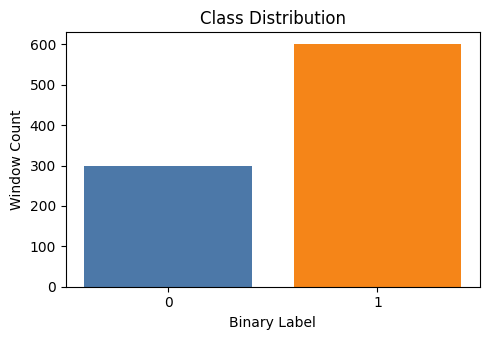

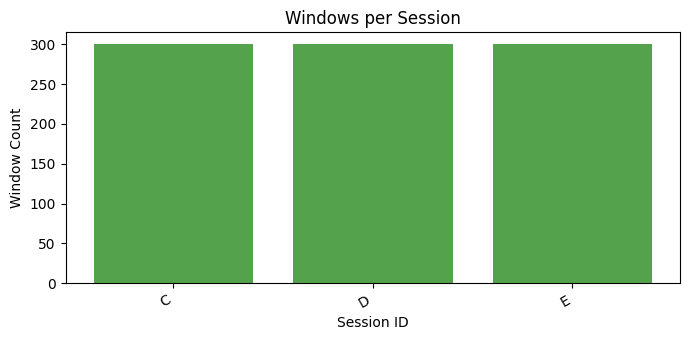

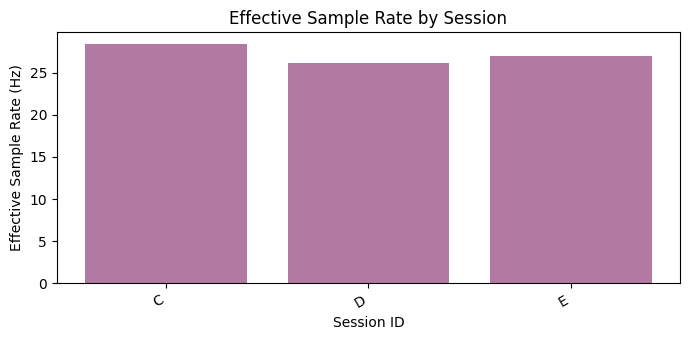

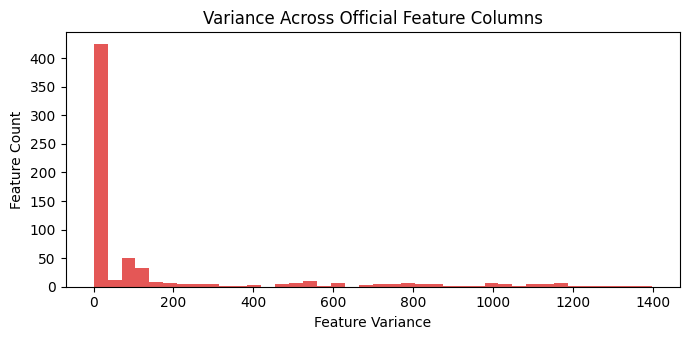

PosixPath('/home/xavier/code/wifi-csi-presence-detection/pilot/outputs/pipeline_v0/figures/feature_variance_distribution_v0.png')

In [14]:
def save_current_figure(filename: str) -> Path:
    """Save the current matplotlib figure to FIGURES_DIR and close it."""
    output_path = FIGURES_DIR / filename
    plt.tight_layout()
    plt.savefig(output_path, dpi=160)
    plt.show()
    plt.close()
    return output_path


class_counts = features_df["label"].value_counts().sort_index()
plt.figure(figsize=(5, 3.5))
plt.bar(class_counts.index.astype(str), class_counts.values, color=["#4C78A8", "#F58518"][: len(class_counts)])
plt.title("Class Distribution")
plt.xlabel("Binary Label")
plt.ylabel("Window Count")
save_current_figure("class_distribution_v0.png")

windows_by_session = features_df.groupby("session_id").size()
plt.figure(figsize=(7, 3.5))
plt.bar(windows_by_session.index.astype(str), windows_by_session.values, color="#54A24B")
plt.title("Windows per Session")
plt.xlabel("Session ID")
plt.ylabel("Window Count")
plt.xticks(rotation=30, ha="right")
save_current_figure("windows_per_session_v0.png")

plt.figure(figsize=(7, 3.5))
plt.bar(session_metrics_df["session_id"].astype(str), session_metrics_df["effective_rate_hz"], color="#B279A2")
plt.title("Effective Sample Rate by Session")
plt.xlabel("Session ID")
plt.ylabel("Effective Sample Rate (Hz)")
plt.xticks(rotation=30, ha="right")
save_current_figure("effective_sample_rate_by_session_v0.png")

feature_variances = features_df[feature_columns].var(axis=0, ddof=1)
plt.figure(figsize=(7, 3.5))
plt.hist(feature_variances.replace([np.inf, -np.inf], np.nan).dropna(), bins=40, color="#E45756")
plt.title("Variance Across Official Feature Columns")
plt.xlabel("Feature Variance")
plt.ylabel("Feature Count")
save_current_figure("feature_variance_distribution_v0.png")


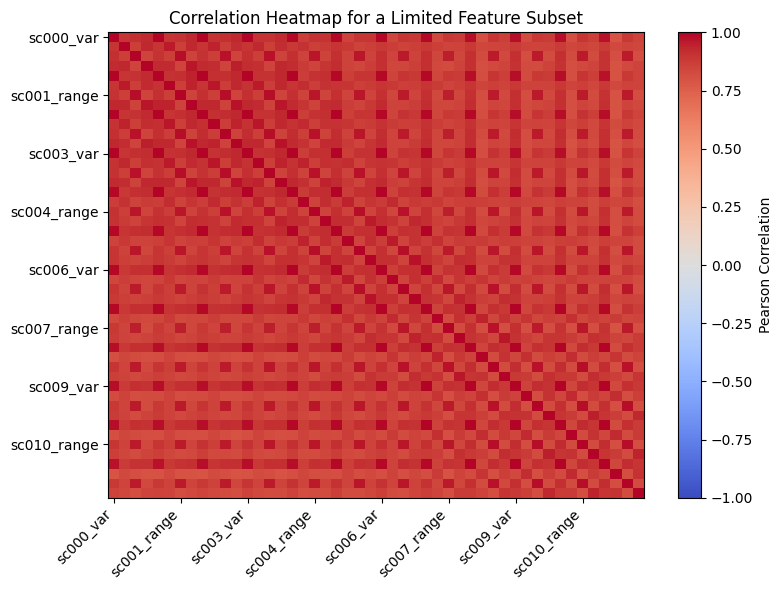

/tmp/ipykernel_88020/705589273.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values, labels=labels, showfliers=False)


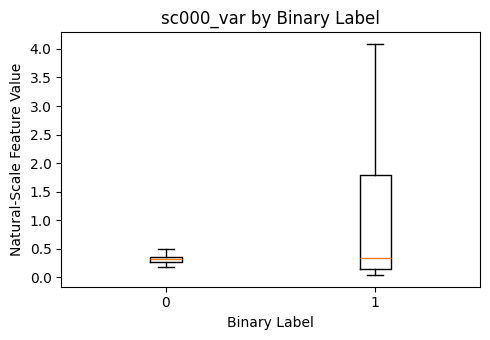

/tmp/ipykernel_88020/705589273.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values, labels=labels, showfliers=False)


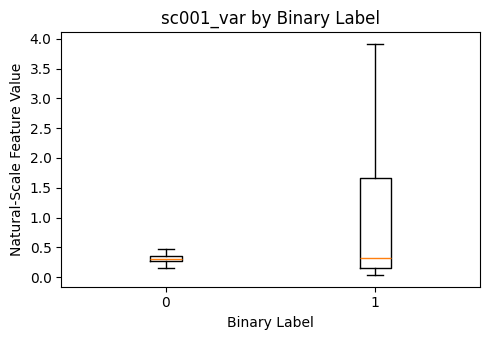

/tmp/ipykernel_88020/705589273.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values, labels=labels, showfliers=False)


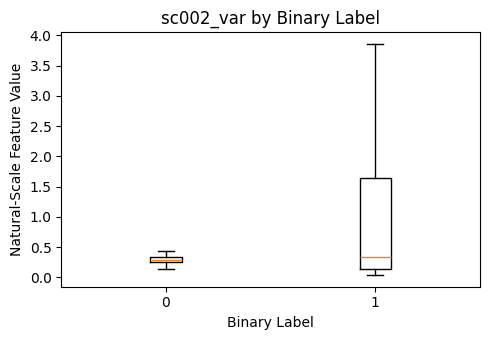

/tmp/ipykernel_88020/705589273.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values, labels=labels, showfliers=False)


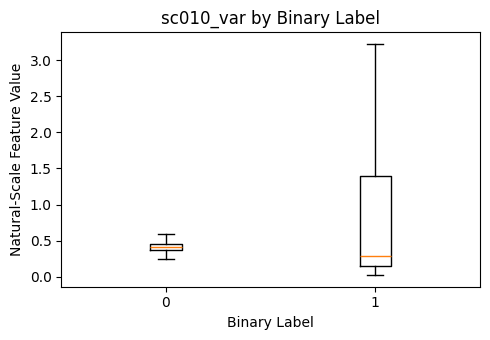

/tmp/ipykernel_88020/705589273.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values, labels=labels, showfliers=False)


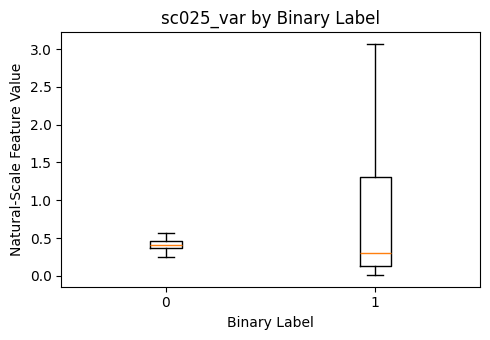

/tmp/ipykernel_88020/705589273.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values, labels=labels, showfliers=False)


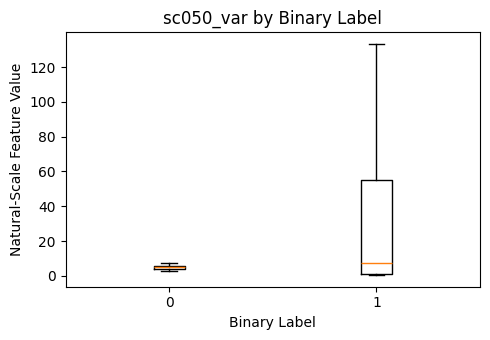

In [15]:
subset_feature_columns = feature_columns[: min(MAX_CORRELATION_FEATURES, len(feature_columns))]
if len(subset_feature_columns) >= 2:
    corr = features_df[subset_feature_columns].corr()
    plt.figure(figsize=(8, 6))
    plt.imshow(corr, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
    plt.colorbar(label="Pearson Correlation")
    plt.title("Correlation Heatmap for a Limited Feature Subset")
    tick_positions = np.arange(len(subset_feature_columns))
    step = max(1, len(subset_feature_columns) // 8)
    plt.xticks(tick_positions[::step], [subset_feature_columns[i] for i in tick_positions[::step]], rotation=45, ha="right")
    plt.yticks(tick_positions[::step], [subset_feature_columns[i] for i in tick_positions[::step]])
    save_current_figure("limited_feature_correlation_heatmap_v0.png")

selected_indices = [
    index
    for index in SELECTED_VALID_SUBCARRIERS_FOR_EDA
    if index < n_shared_valid_subcarriers
][:6]
boxplot_columns = [f"sc{index:03d}_var" for index in selected_indices if f"sc{index:03d}_var" in features_df.columns]
if boxplot_columns:
    for column in boxplot_columns:
        labels = []
        values = []
        for label_value, group in features_df.groupby("label"):
            labels.append(str(label_value))
            values.append(group[column].dropna().to_numpy())
        plt.figure(figsize=(5, 3.5))
        plt.boxplot(values, labels=labels, showfliers=False)
        plt.title(f"{column} by Binary Label")
        plt.xlabel("Binary Label")
        plt.ylabel("Natural-Scale Feature Value")
        save_current_figure(f"boxplot_{column}_by_label_v0.png")


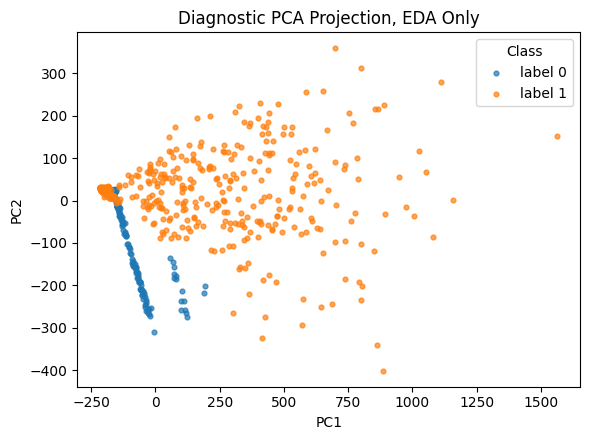

In [16]:
def diagnostic_pca_2d(values: pd.DataFrame, max_rows: int = MAX_PCA_ROWS) -> pd.DataFrame:
    """Compute a simple centered PCA projection for EDA only."""
    clean_values = values.replace([np.inf, -np.inf], np.nan).dropna(axis=1, how="any")
    if clean_values.shape[1] < 2 or clean_values.shape[0] < 2:
        return pd.DataFrame()
    if len(clean_values) > max_rows:
        clean_values = clean_values.sample(max_rows, random_state=RANDOM_SEED)
    centered = clean_values.to_numpy(dtype=np.float64)
    centered = centered - centered.mean(axis=0, keepdims=True)
    _, _, vt = np.linalg.svd(centered, full_matrices=False)
    projected = centered @ vt[:2].T
    return pd.DataFrame(projected, index=clean_values.index, columns=["pc1", "pc2"])


pca_projection_df = diagnostic_pca_2d(features_df[feature_columns])
if not pca_projection_df.empty:
    pca_plot_df = pca_projection_df.join(features_df[["label"]])
    plt.figure(figsize=(6, 4.5))
    for label_value, group in pca_plot_df.groupby("label"):
        plt.scatter(group["pc1"], group["pc2"], s=12, alpha=0.7, label=f"label {label_value}")
    plt.title("Diagnostic PCA Projection, EDA Only")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend(title="Class")
    save_current_figure("diagnostic_pca_2d_v0.png")


## 13. Final Automated Checks

These checks verify that the official dataset uses dynamic HT40 dimensions, contains only the official natural-scale feature columns, and preserves non-overlapping windows.


In [17]:
def assert_non_overlapping_windows(df: pd.DataFrame) -> None:
    """Assert that windows do not overlap within each session."""
    for session_id, group in df.sort_values(["session_id", "window_start_time"]).groupby("session_id"):
        starts = pd.to_datetime(group["window_start_time"]).reset_index(drop=True)
        ends = pd.to_datetime(group["window_end_time"]).reset_index(drop=True)
        if len(group) > 1:
            non_overlapping = starts.iloc[1:].reset_index(drop=True).ge(ends.iloc[:-1].reset_index(drop=True))
            assert bool(non_overlapping.all()), f"Overlapping windows detected in session {session_id}."


feature_count = len(feature_columns)
assert feature_count == 4 * n_shared_valid_subcarriers
assert not features_df[feature_columns].isna().all(axis=0).any()
assert set(features_df["label"].dropna().unique()).issubset({0, 1})
assert all(
    session["metadata_status"] == REQUIRED_METADATA_STATUS for session in loaded_sessions
), "A processed session does not have valid metadata status."
assert raw_subcarrier_count != 64, "The loaded data looks like an HT20-only raw subcarrier layout."
assert n_shared_valid_subcarriers != 51, "The shared mask looks like a legacy reduced-subcarrier layout."
assert feature_count != 4 * 51, "The feature count looks like a legacy fixed feature layout."
assert_non_overlapping_windows(features_df)

forbidden_name_fragments = ["scaled", "standardized", "zscore", "z_score", "normalized"]
forbidden_columns = [
    column
    for column in features_df.columns
    if any(fragment in column.lower() for fragment in forbidden_name_fragments)
]
assert not forbidden_columns, f"Official dataset contains scaling-related columns: {forbidden_columns}"

final_summary = {
    "sessions_processed": len(loaded_sessions),
    "sessions_excluded_due_to_metadata_status": int(len(excluded_sessions_table)),
    "raw_complex_subcarriers": raw_subcarrier_count,
    "shared_valid_ht40_subcarriers": n_shared_valid_subcarriers,
    "official_feature_count": feature_count,
    "windows": int(len(features_df)),
    "class_distribution": features_df["label"].value_counts().sort_index().astype(int).to_dict(),
    "features_csv": str(FEATURE_OUTPUT_CSV),
    "features_parquet": str(FEATURE_OUTPUT_PARQUET) if parquet_written else None,
    "valid_subcarrier_mapping_csv": str(VALID_SUBCARRIER_MAPPING_CSV),
    "pipeline_report_json": str(PIPELINE_REPORT_JSON),
    "figures_dir": str(FIGURES_DIR),
}

print(json.dumps(to_jsonable(final_summary), indent=2))


{
  "sessions_processed": 3,
  "sessions_excluded_due_to_metadata_status": 2,
  "raw_complex_subcarriers": 192,
  "shared_valid_ht40_subcarriers": 162,
  "official_feature_count": 648,
  "windows": 900,
  "class_distribution": {
    "0": 300,
    "1": 600
  },
  "features_csv": "/home/xavier/code/wifi-csi-presence-detection/pilot/outputs/pipeline_v0/features_v0_ht40.csv",
  "features_parquet": "/home/xavier/code/wifi-csi-presence-detection/pilot/outputs/pipeline_v0/features_v0_ht40.parquet",
  "valid_subcarrier_mapping_csv": "/home/xavier/code/wifi-csi-presence-detection/pilot/outputs/pipeline_v0/valid_subcarrier_mapping_v0.csv",
  "pipeline_report_json": "/home/xavier/code/wifi-csi-presence-detection/pilot/outputs/pipeline_v0/pipeline_report_v0.json",
  "figures_dir": "/home/xavier/code/wifi-csi-presence-detection/pilot/outputs/pipeline_v0/figures"
}
